In [15]:
# AlexNet Demonstration Notebook

# Install PyTorch
# !pip install torch torchvision

# Import Libraries
import torch
import torchvision as tv
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from io import BytesIO
import timm
import torch.nn as nn
from torchvision import datasets, models, transforms
import os
from torch.utils.data import DataLoader, Dataset, TensorDataset
import pandas as pd
from utils import sort_images, make_val_loader

In [16]:
def get_percent_correct_from_proba(prob, labels, eps=1e-3):
    nrImages = prob.shape[0]
    
    _,ind = np.unique(labels, return_index=True)
    class_order=np.linspace(0, 9, 10)
    pc = np.zeros((nrImages,len(class_order)))
    pc[:]=np.nan
    
    for i in range(nrImages):
        loc_target = labels[i]==class_order
        pc[i,:] = np.divide(prob[i,labels[i]==class_order]+eps,(prob[i,:]+eps)+(prob[i,loc_target]+eps)) #+eps
        pc[i,loc_target]=np.nan
    return pc

def create_image_level_accuracies(new_features, labels, nrImages=200, eps=1e-5):
    if labels is None:
        lb = ["bear", "elephant", "person", "car", "dog", "apple", "chair", "plane", "bird", "zebra"]
        labels = np.repeat(lb, nrImages // len(lb), axis=0)

    i1 = np.zeros((new_features.shape[0]), dtype=float)
    i1[:] = np.nan

    pc = get_percent_correct_from_proba(new_features, labels, eps)
    i1[:] = np.nanmean(pc, axis=1)

    return i1, pc

In [17]:
# #AlexNet Model
model = models.alexnet(pretrained=True)
weights = torch.load("checkpoints/alexnet_fine_tuned.pth")
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)

#ResNet50 Model
# model = models.resnet50(pretrained=True)
# weights = torch.load("checkpoints/resnet50_fine_tuned.pth")
# model.fc = torch.nn.Linear(model.fc.in_features, 10)

# #ConvNeXt Model
# model = timm.create_model("convnext_base", pretrained=True)
# weights = torch.load("checkpoints/convnext_fine_tuned.pth", map_location="cpu")
# model.head.fc = torch.nn.Linear(1024, 10)

model.load_state_dict(weights)
model.eval()

/Users/sabine/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/sabine/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [18]:
data_loader = make_val_loader("../images/draw_2AFC", 4)
labels = [0, 1, 4, 5]

In [19]:
probabilities = []
with torch.no_grad():
    for inputs in data_loader:
        inputs = inputs[0]
        output = model(inputs)
        output = torch.nn.functional.softmax(output, dim=-1)
        probabilities.append(output.detach().cpu().numpy())
probabilities = np.concatenate(probabilities, axis=0)

In [20]:
preds = np.argmax(probabilities, axis=1)
(preds == labels).mean() #Overall accuracy

np.float64(0.0)

In [21]:
#Binary version of the task
image_scores, model_choices = create_image_level_accuracies(probabilities, labels=labels)
image_scores.mean()

np.float64(0.20027197808387123)

Text(0.5, 0, 'Accuracy')

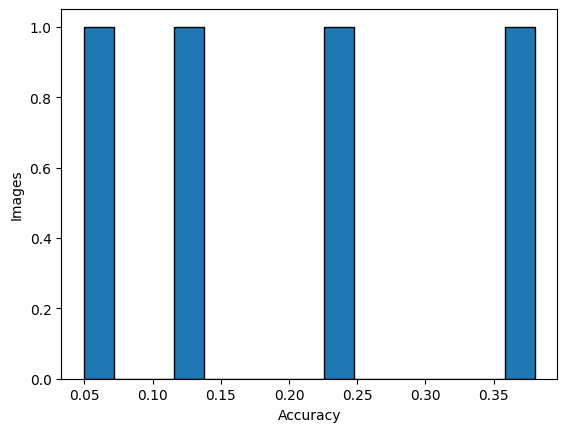

In [22]:
plt.hist(image_scores, bins=15, edgecolor="black")
plt.ylabel("Images")
plt.xlabel("Accuracy")

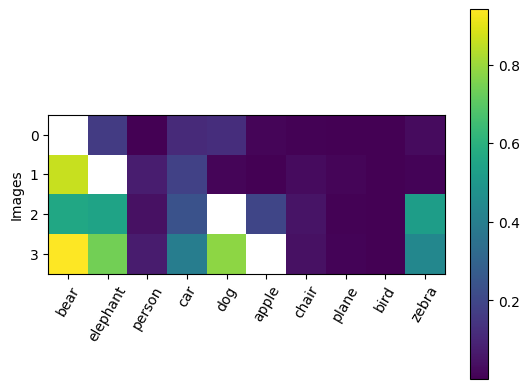

In [23]:
model_choices.shape #number of images, number of choices
lb = ["bear", "elephant", "person", "car", "dog", "apple", "chair", "plane", "bird", "zebra"]
plt.imshow(model_choices)
plt.xticks(np.linspace(0, 9, 10), lb, rotation=60)
plt.ylabel("Images")
plt.colorbar()


In [24]:
indices = sort_images(os.listdir("../images/draw_2AFC"))
images = [f'im{x}.png' for x in indices]

In [25]:
# Create dataframe
df = pd.DataFrame({
    "image_name": images,
    "image_index": indices,
    "accuracy": image_scores
})

# Save to CSV
df.to_csv("results/draw_2afc.csv", index=False)